# Kwartieranalyse — Energie per 15 minuten

Dit notebook analyseert alle energiemetingen op kwartiersniveau (15 min).
De **Fluvius digitale meter** levert de basis: één lijn per kwartier met afname en injectie,
aangevuld met een tarief-indicator (dag/nacht) en data uit alle overige bronnen.


In [11]:
import sys
from pathlib import Path

# Projectroot op sys.path zodat scripts-pakket vindbaar is
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import scripts.overall as overall
import scripts.fluvius as fluvius
from scripts.owndev import OVERALL_FILE


## 1. Bouw het kwartierbestand

`overall.bouw()` laadt de Fluvius-data als basis, bepaalt het tarief (dag/nacht) per kwartier
en verrijkt met OwnDev, SolarLogs, Battery, Solarcharge en weerdata.
Het resultaat wordt opgeslagen in `data/Final/overall.csv`.


In [12]:
importlib.reload(overall)

df, pad = overall.bouw()
print(f'Opgeslagen: {pad}')
print(f'Kwartieren : {len(df)}')
print(f'Kolommen   : {list(df.columns)}')
df.head()


Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\overall.csv
Kwartieren : 50104
Kolommen   : ['kwartier', 'afname_kwh', 'injectie_kwh', 'tarief', 'fl_afname_dag', 'fl_afname_nacht', 'fl_injectie_dag', 'fl_injectie_nacht', 'bat_laden_kw', 'bat_ontladen_kw', 'afname_kw', 'terugave_kw', 'soc_begin', 'soc_eind', 'n_seconden', 'sl_afname_kwh', 'sl_injectie_kwh', 'sl_productie_kwh', 'bat_geladen_kwh', 'bat_ontladen_kwh', 'bat_soc_uur', 'weer_poa_w_m2', 'weer_ghi_w_m2', 'weer_zon_min', 'ev_energie_kwh', 'ev_vermogen_kw']


,kwartier,afname_kwh,injectie_kwh,tarief,fl_afname_dag,fl_afname_nacht,fl_injectie_dag,fl_injectie_nacht,bat_laden_kw,bat_ontladen_kw,...,sl_injectie_kwh,sl_productie_kwh,bat_geladen_kwh,bat_ontladen_kwh,bat_soc_uur,weer_poa_w_m2,weer_ghi_w_m2,weer_zon_min,ev_energie_kwh,ev_vermogen_kw
0,2024-11-01 00:00:00,0.229,0.009,nacht,0.0,0.229,0.0,0.009,NaN,NaN,...,0.0,0.0,1.0,0.0,12.0,0.0,0.0,0.0,NaN,NaN
1,2024-11-01 00:15:00,0.642,0.000,nacht,0.0,0.642,0.0,0.000,NaN,NaN,...,0.0,0.0,1.0,0.0,12.0,0.0,0.0,0.0,NaN,NaN
2,2024-11-01 00:30:00,0.574,0.000,nacht,0.0,0.574,0.0,0.000,NaN,NaN,...,0.0,0.0,1.0,0.0,12.0,0.0,0.0,0.0,NaN,NaN
3,2024-11-01 00:45:00,0.363,0.000,nacht,0.0,0.363,0.0,0.000,NaN,NaN,...,0.0,0.0,1.0,0.0,12.0,0.0,0.0,0.0,NaN,NaN
4,2024-11-01 01:00:00,0.390,0.000,nacht,0.0,0.390,0.0,0.000,NaN,NaN,...,0.0,0.0,1.0,0.0,21.0,0.0,0.0,0.0,NaN,NaN


## 2. Structuur en basisstatistieken

Overzicht van de data: datatypes, periode en beschrijvende statistieken.


In [13]:
print('Periode:', df['kwartier'].min(), '→', df['kwartier'].max())
print('Kwartieren:', len(df))
print()
print('Tariefsplitsing:')
print(df['tarief'].value_counts().to_string())
print()
df.describe(include='all').round(3)


Periode: 2024-11-01 00:00:00 → 2026-04-06 23:45:00
Kwartieren: 50104

Tariefsplitsing:
tarief
nacht    28959
dag      21145



,kwartier,afname_kwh,injectie_kwh,tarief,fl_afname_dag,fl_afname_nacht,fl_injectie_dag,fl_injectie_nacht,bat_laden_kw,bat_ontladen_kw,...,sl_injectie_kwh,sl_productie_kwh,bat_geladen_kwh,bat_ontladen_kwh,bat_soc_uur,weer_poa_w_m2,weer_ghi_w_m2,weer_zon_min,ev_energie_kwh,ev_vermogen_kw
count,50104,50104.000,50104.000,50104,50104.000,50104.000,50104.000,50104.000,1570.000,1570.000,...,50104.000,50104.0,46376.000,46376.000,46376.000,50104.000,50104.000,50104.000,5729.000,5729.000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,nacht,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,28959,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-07-19 23:36:22.891585,0.231,0.005,NaN,0.069,0.162,0.004,0.002,0.144,0.122,...,0.020,0.0,0.169,0.156,18.622,99.234,118.082,17.506,0.604,2.411
min,2024-11-01 00:00:00,0.000,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.0,-1.000,0.000,0.000,0.000,0.000,0.000,0.002,0.007
25%,2025-03-11 11:26:15,0.025,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.495,1.979
50%,2025-07-19 23:52:30,0.138,0.000,NaN,0.000,0.008,0.000,0.000,0.000,0.000,...,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.560,2.238
75%,2025-11-27 11:18:45,0.301,0.001,NaN,0.041,0.198,0.000,0.000,0.046,0.011,...,0.010,0.0,0.000,0.000,25.000,77.700,165.000,60.000,0.671,2.685
max,2026-04-06 23:45:00,2.080,0.638,NaN,1.779,2.080,0.638,0.616,2.364,2.429,...,2.130,0.0,8.000,4.000,100.000,923.520,889.000,60.000,3.262,13.047


## 3. Analyse van de beschikbare data

Overzicht van de meetperiode en het aantal dagen waarop elke bron
effectief data heeft geleverd.


In [14]:
import pandas as pd

# Datum-kolom aanmaken
df['datum'] = pd.to_datetime(df['kwartier']).dt.date

# ── Periodeinfo ────────────────────────────────────────────────────────────
begindatum  = df['datum'].min()
einddatum   = df['datum'].max()
alle_dagen  = pd.date_range(begindatum, einddatum, freq='D')
n_alle_dagen = len(alle_dagen)

# ── Dagen met meting per bron ──────────────────────────────────────────────
# iLumen batterij: bat_geladen_kwh of bat_ontladen_kwh aanwezig (niet NaN en > 0)
dagen_ilumen_bat = (
    df[df['bat_geladen_kwh'].notna() | df['bat_ontladen_kwh'].notna()]
    ['datum'].nunique()
)

# iLumen SolarLogs: sl_productie_kwh aanwezig
dagen_ilumen_sol = (
    df[df['sl_productie_kwh'].notna()]
    ['datum'].nunique()
)

# OwnDev: n_seconden aanwezig (er is minstens één kwartier met secondedata)
dagen_owndev = (
    df[df['n_seconden'].notna()]
    ['datum'].nunique()
)

# Zon: minstens één kwartier in de dag met zonneschijn > 0
dagen_zon = (
    df[df['weer_zon_min'].fillna(0) > 0]
    ['datum'].nunique()
)

# Zon: gemiddeld aantal uur zon op dagen dat er zon was
zon_per_dag = (
    df.groupby('datum')['weer_zon_min']
    .apply(lambda x: x.fillna(0).sum() / 4 / 60)   # kwartier -> uur
)
gem_zon_op_zondagen = zon_per_dag[zon_per_dag > 0].mean()
totale_zon_uren = zon_per_dag.sum()

# ── Rapport ────────────────────────────────────────────────────────────────
print('=' * 52)
print('  DATA-ANALYSE KWARTIERBESTAND')
print('=' * 52)
print(f'  Begindatum              : {begindatum}')
print(f'  Einddatum               : {einddatum}')
print(f'  Totaal aantal dagen     : {n_alle_dagen}')
print()
print('  MEETDAGEN PER BRON')
print(f'  {"Bron":<30} {"dagen":>5}  {"van":>5}')
print('  ' + '-' * 44)
print(f'  {"iLumen batterij":<30} {dagen_ilumen_bat:>5}  {n_alle_dagen:>5}')
print(f'  {"iLumen SolarLogs":<30} {dagen_ilumen_sol:>5}  {n_alle_dagen:>5}')
print(f'  {"OwnDev (P1 + SOFAR)":<30} {dagen_owndev:>5}  {n_alle_dagen:>5}')
print()
print('  ZONNESCHIJN')
print(f'  Dagen met zonneschijn   : {dagen_zon}  van  {n_alle_dagen}')
print(f'  Totale zonneschijn      : {totale_zon_uren:.1f} uur')
print(f'  Gem. zon op zondagen    : {gem_zon_op_zondagen:.1f} uur/dag')
print('=' * 52)


  DATA-ANALYSE KWARTIERBESTAND
  Begindatum              : 2024-11-01
  Einddatum               : 2026-04-06
  Totaal aantal dagen     : 522

  MEETDAGEN PER BRON
  Bron                           dagen    van
  --------------------------------------------
  iLumen batterij                  492    522
  iLumen SolarLogs                 522    522
  OwnDev (P1 + SOFAR)               18    522

  ZONNESCHIJN
  Dagen met zonneschijn   : 465  van  522
  Totale zonneschijn      : 3654.7 uur
  Gem. zon op zondagen    : 7.9 uur/dag


## 4. Verbruiksanalyse: EV en batterij buiten beschouwing

### Methodologie

De ruwe Fluvius-data (`afname_kwh`, `injectie_kwh`) beschrijft de wisselwerking
met het distributienet. Die meting is echter vertekend door variabele elementen
die niet behoren tot het basisverbruik van het gebouw:

1. **EV-lading**: het opladen van de wagen verhoogt de afname sterk tijdens
   laadsessies, maar is geen 'huishoudelijk' verbruik.

2. **Batterijherverdeling**: de batterij verplaatst energie in de tijd.
   Ontlading levert energie aan het huis (+), lading onttrekt energie van
   het huis (â). Beide correcties zijn nodig om het patroon te reconstrueren
   zoals het er zonder batterij zou uitzien.

De gecorrigeerde verbruikskolom is:

```
verbruik_kwh = afname_kwh + bat_ontladen - injectie_kwh - ev_kwh - bat_laden
```

Dit is de **netto belasting op externe bronnen**: hoeveel energie het huis netto
van het net en de batterijontlading opnam, na aftrek van EV en injectie.

**Opmerking over zonnepanelen**: op zonnige kwartieren is een deel van het
werkelijke verbruik afkomstig van de panelen (zelfconsumptie). Die zelfconsumptie
loopt niet via de Fluvius-meter. `verbruik_kwh` zal daardoor op zonnige middagen
lager zijn dan het werkelijke huisverbruik â dat is geen meetfout, maar een
correcte weerspiegeling van het feit dat de zon op die momenten een deel van de
vraag dekt. Voor een kwantitatieve schatting van de PV-opbrengst: zie sectie 5.


In [24]:
import numpy as np
import pandas as pd

# ── Hulpkolommen op kwartiersniveau ───────────────────────────────────────────
# EV: NaN = geen laadsessie
df['ev_kwh'] = df['ev_energie_kwh'].fillna(0)

# Batterijcorrectie:
#   OwnDev geeft gemiddeld vermogen (kW) per kwartier → kWh = kW * 0.25
#   Als OwnDev ontbreekt, valt men terug op iLumen-uurwaarden (/4).
def bat_kwh(kw_col, kwh_col):
    """kW * 0.25 als beschikbaar, anders uurkwh / 4, anders 0."""
    od  = df[kw_col].fillna(0)  * 0.25
    il  = df[kwh_col].fillna(0) / 4
    return od.where(df[kw_col].notna(), il)

df['bat_ontladen_kwh_kw'] = bat_kwh('bat_ontladen_kw', 'bat_ontladen_kwh')
df['bat_laden_kwh_kw']    = bat_kwh('bat_laden_kw',    'bat_geladen_kwh')

# ── Netto belasting op externe bronnen ─────────────────────────────────────
# Energiebalans per kwartier:
#   verbruik_kwh = afname + bat_ontladen − injectie − ev − bat_laden
#
# Dit is wat het huis netto opnam van het net en de batterijontlading,
# gecorrigeerd voor EV-laden en batterijlading.
# Op zonnige kwartieren is verbruik_kwh lager dan het werkelijke huisverbruik
# omdat de PV-zelfconsumptie niet via de Fluvius-meter loopt.
# Negatieve waarden (meetruis) worden weggeclipt.
df['verbruik_kwh'] = (
    df['afname_kwh']
    + df['bat_ontladen_kwh_kw']
    - df['injectie_kwh']
    - df['ev_kwh']
    - df['bat_laden_kwh_kw']
).clip(lower=0)

print('Verbruikskolom aangemaakt:')
print(f'  min  : {df["verbruik_kwh"].min():.4f} kWh')
print(f'  gem  : {df["verbruik_kwh"].mean():.4f} kWh')
print(f'  max  : {df["verbruik_kwh"].max():.4f} kWh')

# ── Opslaan: verrijkt kwartierbestand ──────────────────────────────────────────
from pathlib import Path
from scripts.config import FINAL_DIR

kolommen_verrijkt = [
    'kwartier', 'afname_kwh', 'injectie_kwh', 'tarief',
    'fl_afname_dag', 'fl_afname_nacht', 'fl_injectie_dag', 'fl_injectie_nacht',
    'bat_laden_kw', 'bat_ontladen_kw', 'afname_kw', 'terugave_kw',
    'soc_begin', 'soc_eind', 'n_seconden',
    'sl_afname_kwh', 'sl_injectie_kwh', 'sl_productie_kwh',
    'bat_geladen_kwh', 'bat_ontladen_kwh', 'bat_soc_uur',
    'weer_poa_w_m2', 'weer_ghi_w_m2', 'weer_zon_min',
    'ev_energie_kwh', 'ev_vermogen_kw',
    'ev_kwh', 'bat_ontladen_kwh_kw', 'bat_laden_kwh_kw', 'verbruik_kwh',
]
kolommen_aanwezig = [k for k in kolommen_verrijkt if k in df.columns]
pad_verrijkt = FINAL_DIR / 'overall_verrijkt.csv'
df[kolommen_aanwezig].to_csv(pad_verrijkt, index=False,
                             date_format='%Y-%m-%d %H:%M:%S')
print(f'Opgeslagen: {pad_verrijkt}  ({len(df)} rijen, {len(kolommen_aanwezig)} kolommen)')


Verbruikskolom aangemaakt:
  min  : 0.0000 kWh
  gem  : 0.1779 kWh
  max  : 1.6040 kWh
Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\overall_verrijkt.csv  (50104 rijen, 30 kolommen)


### Weekpatroon: gecorrigeerd verbruik per kwartier per dag van de week

Het weekpatroon toont de **netto belasting op externe bronnen** per kwartier
van de dag, per weekdag. Twee correcties zijn toegepast op de ruwe Fluvius-afname:

1. **EV-lading aftrekken** — het opladen van de wagen is geen huisverbruik.
2. **Batterijherverdeling corrigeren** — ontlading telt als extra bron (+),
   lading als opgeslagen energie (−).

Zonnepanelen zijn *niet* apart gecorrigeerd: op zonnige middagen is `verbruik_kwh`
lager omdat PV een deel van de vraag rechtstreeks dekt. Die daling is reële en
informatief — ze toont wanneer de eigen productie de belasting op het net verkleint.

Elk datapunt is het **gemiddelde over alle gelijkaardige kwartieren** in de dataset.
De heatmap en het lijnplot tonen het patroon per weekdag.


Gemiddeld verbruik (kWh/kwartier) per weekdag en tijdstip
(eerste en laatste uren getoond):


,Maandag,Dinsdag,Woensdag,Donderdag,Vrijdag,Zaterdag,Zondag
00:00,0.1428,0.1579,0.1392,0.1524,0.1476,0.1509,0.1798
00:15,0.1749,0.1766,0.1678,0.1675,0.1860,0.1571,0.1715
00:30,0.1787,0.1729,0.1605,0.1683,0.1807,0.1384,0.1681
00:45,0.1576,0.1682,0.1615,0.1552,0.1878,0.1347,0.1596
01:00,0.1380,0.1492,0.1306,0.1384,0.1475,0.1529,0.1692
01:15,0.1427,0.1784,0.1446,0.1589,0.1489,0.1495,0.1773
01:30,0.1373,0.1652,0.1412,0.1677,0.1624,0.1604,0.1697
01:45,0.1385,0.1589,0.1440,0.1578,0.1495,0.1511,0.1726
11:00,0.1094,0.1169,0.1012,0.1435,0.1707,0.1292,0.2404
11:15,0.0903,0.1068,0.1040,0.1539,0.1614,0.1253,0.2621


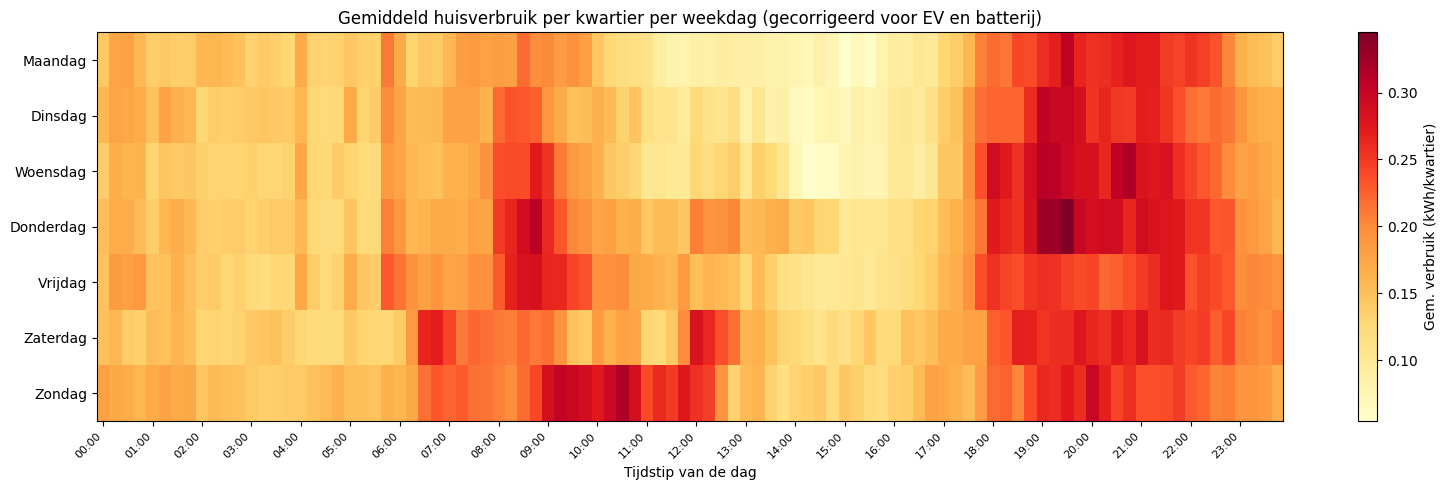

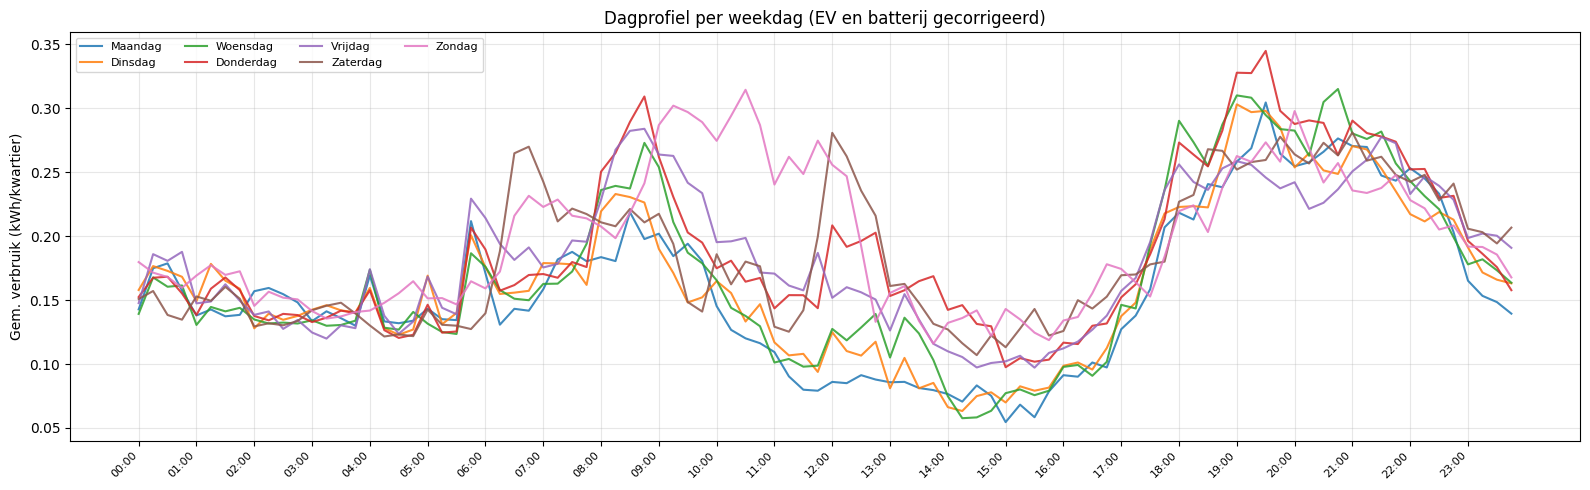

Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\weekpatroon.csv  (96 rijen x 7 weekdagen)


In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

WEEKDAGEN = ['Maandag','Dinsdag','Woensdag','Donderdag','Vrijdag','Zaterdag','Zondag']

# Hulpkolommen
df['dag_van_week']    = pd.to_datetime(df['kwartier']).dt.dayofweek   # 0=ma ... 6=zo
df['kwartier_van_dag'] = (
    pd.to_datetime(df['kwartier']).dt.hour * 4
    + pd.to_datetime(df['kwartier']).dt.minute // 15
)  # 0..95

# Gemiddeld verbruik per (weekdag, kwartier van dag)
week = (
    df.groupby(['dag_van_week', 'kwartier_van_dag'])['verbruik_kwh']
    .mean()
    .unstack(level=0)   # kolommen = weekdag 0..6
)
week.columns = [WEEKDAGEN[i] for i in week.columns]

# Tijdas: kwartier 0..95 -> HH:MM labels
tijdlabels = [
    f'{h:02d}:{m:02d}'
    for h in range(24) for m in (0, 15, 30, 45)
]

# ── Tabel ────────────────────────────────────────────────────────────────
tabel = week.copy()
tabel.index = tijdlabels
print('Gemiddeld verbruik (kWh/kwartier) per weekdag en tijdstip')
print('(eerste en laatste uren getoond):')
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_columns', 10):
    display(pd.concat([tabel.head(8), tabel.iloc[44:52], tabel.tail(8)]))

# ── Heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(
    week.T.values,          # rijen = weekdagen, kolommen = kwartieren
    aspect='auto',
    cmap='YlOrRd',
    interpolation='nearest'
)
plt.colorbar(im, ax=ax, label='Gem. verbruik (kWh/kwartier)')
ax.set_yticks(range(7))
ax.set_yticklabels(WEEKDAGEN)
# X-as: elk uur een label
uur_ticks = list(range(0, 96, 4))
ax.set_xticks(uur_ticks)
ax.set_xticklabels([tijdlabels[i] for i in uur_ticks], rotation=45, ha='right', fontsize=8)
ax.set_title('Gemiddeld huisverbruik per kwartier per weekdag (gecorrigeerd voor EV en batterij)')
ax.set_xlabel('Tijdstip van de dag')
plt.tight_layout()
plt.show()

# ── Lijnplot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
kleuren = plt.cm.tab10.colors
for i, dag in enumerate(WEEKDAGEN):
    ax.plot(range(96), week[dag], color=kleuren[i], lw=1.5,
            label=dag, alpha=0.85)
ax.set_xticks(uur_ticks)
ax.set_xticklabels([tijdlabels[i] for i in uur_ticks], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Gem. verbruik (kWh/kwartier)')
ax.set_title('Dagprofiel per weekdag (EV en batterij gecorrigeerd)')
ax.legend(loc='upper left', fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Opslaan: weekpatroon ─────────────────────────────────────────────────
# Elke rij = één kwartier van de dag (0..95, = 0:00 t/m 23:45).
# Elke kolom = een weekdag (Maandag..Zondag).
# Waarden zijn het gemiddeld huisverbruik in kWh over alle gelijkaardige
# kwartieren in de dataset, gecorrigeerd voor EV en batterijherverdeling.
# Dit patroon dient als inputfeature voor vraag-voorspellingsmodellen.
from scripts.config import FINAL_DIR
pad_week = FINAL_DIR / 'weekpatroon.csv'
week_export = week.copy()
week_export.index.name = 'kwartier_van_dag'
week_export['tijdstip'] = [
    f'{h:02d}:{m:02d}' for h in range(24) for m in (0, 15, 30, 45)
]
week_export = week_export[['tijdstip'] + WEEKDAGEN]
week_export.to_csv(pad_week)
print(f'Opgeslagen: {pad_week}  ({len(week_export)} rijen x {len(WEEKDAGEN)} weekdagen)')


### Verhouding zonneschijn ↔ injectie naar het net

Omdat de SolarLogs-API geen afzonderlijke productiemeting levert (het veld
`production` is doorlopend 0), gebruiken we de **injectie naar het net**
(`injectie_kwh` uit de Fluvius-data) als proxy voor zonne-activiteit.

Die keuze is verdedigbaar:
- Bij weinig zon is de injectie (quasi) nul.
- Bij veel zon stijgt de injectie naarmate de productie de directe
  huisbehoefte overschrijdt.
- De injectie **onderschat** de werkelijke productie (zelfconsumptie is
  niet zichtbaar), maar de **rangorde** tussen zonnige en bewolkte dagen
  blijft correct.

We berekenen twee verhoudingen:

| Verhouding | Formule | Interpretatie |
|---|---|---|
| kWh injectie per zonuur | `injectie / (zon_min / 60)` | Gemiddeld injectievermogen tijdens zonneschijn |
| kWh injectie per kWh/m² POA | `injectie / poa_kwh_m2` | Injectie-rendement t.o.v. instraling |

Een hoge correlatie bevestigt dat POA-instraling bruikbaar is als proxy
voor de netto zonne-opbrengst, zelfs zonder productiemeter.


Dagen met zon en injectiedata : 465
Correlatie zonneschijnduur ↔ injectie : r = 0.407
Correlatie POA-instraling  ↔ injectie : r = 0.459

Gem. injectie per uur zonneschijn     : 0.113 kWh/uur
Gem. injectie per kWh/m² POA          : 0.229 kWh/(kWh/m²)

Regressieparameters:
  injectie = 0.0016 x zon_min    + -0.185
  injectie = 0.2261 x poa_kwh_m2 + -0.047


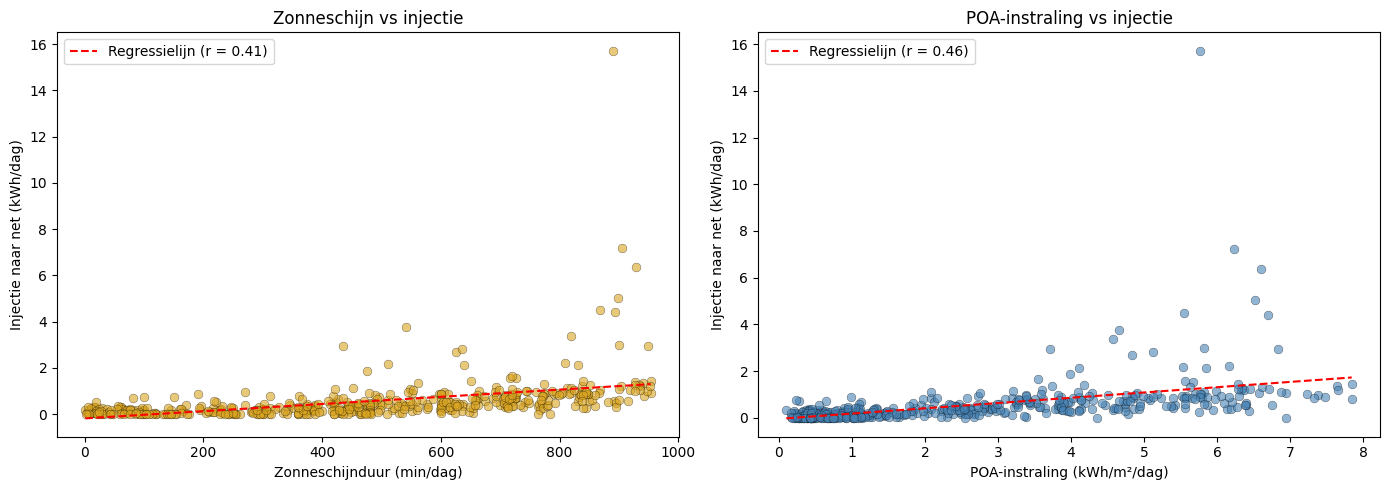

Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\dag_zon_analyse.csv  (522 rijen)
Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\dag_zon_met_verhoudingen.csv  (465 rijen)


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# dag-aggregatie aanmaken (injectie + weerdata per kalenderdag)
dag = df.groupby('datum').agg(
    injectie_kwh = ('injectie_kwh', 'sum'),
    zon_min      = ('weer_zon_min',  lambda x: x.fillna(0).sum() / 4),
    poa_kwh_m2   = ('weer_poa_w_m2', lambda x: x.fillna(0).sum() / 4 / 1000),
).round(4)

# Filter op dagen met zonneschijn én injectiedata
zon_dag = dag[
    (dag['zon_min'] > 0) &
    (dag['poa_kwh_m2'] > 0) &
    dag['injectie_kwh'].notna()
].copy()

print(f'Dagen met zon en injectiedata : {len(zon_dag)}')

if len(zon_dag) < 3:
    print()
    print('Te weinig overlappende data voor regressie.')
    print('Controleer of de weerdata en Fluvius-data dezelfde periode bestrijken.')
else:
    zon_dag['inj_per_zonuur'] = zon_dag['injectie_kwh'] / (zon_dag['zon_min'] / 60)
    zon_dag['inj_per_poa']   = zon_dag['injectie_kwh'] / zon_dag['poa_kwh_m2']

    r_zon = zon_dag['zon_min'].corr(zon_dag['injectie_kwh'])
    r_poa = zon_dag['poa_kwh_m2'].corr(zon_dag['injectie_kwh'])

    coef_zon = np.polyfit(zon_dag['zon_min'],    zon_dag['injectie_kwh'], 1)
    coef_poa = np.polyfit(zon_dag['poa_kwh_m2'], zon_dag['injectie_kwh'], 1)

    print(f'Correlatie zonneschijnduur ↔ injectie : r = {r_zon:.3f}')
    print(f'Correlatie POA-instraling  ↔ injectie : r = {r_poa:.3f}')
    print()
    print(f'Gem. injectie per uur zonneschijn     : {zon_dag["inj_per_zonuur"].mean():.3f} kWh/uur')
    print(f'Gem. injectie per kWh/m² POA          : {zon_dag["inj_per_poa"].mean():.3f} kWh/(kWh/m²)')
    print()
    print('Regressieparameters:')
    print(f'  injectie = {coef_zon[0]:.4f} x zon_min    + {coef_zon[1]:.3f}')
    print(f'  injectie = {coef_poa[0]:.4f} x poa_kwh_m2 + {coef_poa[1]:.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(zon_dag['zon_min'], zon_dag['injectie_kwh'],
               alpha=0.6, color='goldenrod', edgecolors='k', linewidths=0.3, s=40)
    x_l = np.linspace(zon_dag['zon_min'].min(), zon_dag['zon_min'].max(), 100)
    ax.plot(x_l, np.polyval(coef_zon, x_l), 'r--', lw=1.5,
            label=f'Regressielijn (r = {r_zon:.2f})')
    ax.set_xlabel('Zonneschijnduur (min/dag)')
    ax.set_ylabel('Injectie naar net (kWh/dag)')
    ax.set_title('Zonneschijn vs injectie')
    ax.legend()

    ax = axes[1]
    ax.scatter(zon_dag['poa_kwh_m2'], zon_dag['injectie_kwh'],
               alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.3, s=40)
    x_l = np.linspace(zon_dag['poa_kwh_m2'].min(), zon_dag['poa_kwh_m2'].max(), 100)
    ax.plot(x_l, np.polyval(coef_poa, x_l), 'r--', lw=1.5,
            label=f'Regressielijn (r = {r_poa:.2f})')
    ax.set_xlabel('POA-instraling (kWh/m²/dag)')
    ax.set_ylabel('Injectie naar net (kWh/dag)')
    ax.set_title('POA-instraling vs injectie')
    ax.legend()

    plt.tight_layout()
    plt.show()

# ── Opslaan: dagelijkse zon- en injectieanalyse ──────────────────────────
# Eén rij per kalenderdag met: totale injectie (kWh), zonneschijnduur (min),
# POA-instraling (kWh/m²) en de berekende verhoudingen.
# Bruikbaar als trainingsdata voor een productiemodel op dagbasis.
from scripts.config import FINAL_DIR
pad_dag = FINAL_DIR / 'dag_zon_analyse.csv'
dag_export = dag.copy()
dag_export.index.name = 'datum'
dag_export.to_csv(pad_dag)
print(f'Opgeslagen: {pad_dag}  ({len(dag_export)} rijen)')

if len(zon_dag) >= 3:
    pad_zon = FINAL_DIR / 'dag_zon_met_verhoudingen.csv'
    zon_dag.index.name = 'datum'
    zon_dag.to_csv(pad_zon)
    print(f'Opgeslagen: {pad_zon}  ({len(zon_dag)} rijen)')


### Conclusies

**Gecorrigeerd verbruik**

De netto belasting op externe bronnen per kwartier corrigeert de ruwe Fluvius-afname
voor twee variabele elementen: EV-lading en batterijherverdeling. Het resultaat
toont hoeveel energie het huis netto van het net en de batterij opnam. Op zonnige
middagen is dit cijfer lager dan het werkelijke huisverbruik — de PV-zelfconsumptie
loopt immers niet via de Fluvius-meter.

**Weekpatroon**

De heatmap en het lijnplot tonen het typische 24u-patroon per weekdag:
- **Ochtendpiek** (6u–9u): verwarmings- en kookactiviteit;
- **Avondpiek** (17u–22u): verlichting, koken, elektrische apparaten;
- **Nachtdal** (0u–5u): enkel standby-verbruik en eventuele nachtlading;
- **Zomerse middagdip**: lagere netafname doordat PV de vraag deels dekt;
- **Weekend vs. werkdag**: later opstaan en latere ochtendpiek.

**Injectie als proxy voor zon**

De correlatie tussen POA-instraling en dagelijkse injectie bevestigt dat weerdata
een bruikbare maar geen perfecte proxy is. De zelfconsumptie — die niet zichtbaar
is in de netmeting — verklaart de resterende variantie.


## 5. PV-opbrengst versus instraling

### Methodologie

De PV-opbrengst per kwartier wordt afgeleid uit de energiebalans:

```
PV + afname + bat_ontladen = verbruik_huis + ev_kwh + injectie + bat_laden
```

Hieruit volgt:

```
pv_yield = basis_verbruik + ev_kwh + injectie + bat_laden - bat_ontladen - afname
```

waarbij `basis_verbruik` het **gemiddeld huishoudelijk verbruik** is voor dat
kwartier van de dag — berekend als mediaan van alle kwartieren zonder zon, zonder
EV en zonder batterijactiviteit.

Door batterij- en EV-stromen expliciet te verrekenen, kan de berekening worden
uitgevoerd voor **alle zonnige kwartieren**, inclusief die waarbij de batterij
actief is. Kwartieren zonder instraling (POA ≈ 0) krijgen PV-yield = 0.

Negatieve uitkomsten (meetruis of afwijkend verbruik) worden weggeclipt op 0.

Als eerste stap worden de weergegevens ververst zodat de volledige periode
van de Fluvius-data gedekt is.


In [27]:
import scripts.weather as weather
import scripts.overall as overall
import importlib
import pandas as pd
from scripts.config import FINAL_DIR

# ── Stap 1: weerdata verversen ──────────────────────────────────────────────────────
# Bepaal de periodevan de Fluvius-data en haal weerdata op voor die volledige periode.
importlib.reload(weather)
ts_min = pd.to_datetime(df['kwartier'].min()).date()
ts_max = pd.to_datetime(df['kwartier'].max()).date()
print(f'Weerdata ophalen: {ts_min} → {ts_max} ...')
pad_weer = weather.fetch_and_save(str(ts_min), str(ts_max))
print(f'Weerdata opgeslagen: {pad_weer}')

# overall opnieuw bouwen met vernieuwde weerdata
importlib.reload(overall)
print('overall.csv herbouwen ...')
df, _ = overall.bouw()
print(f'overall.csv klaar: {len(df)} kwartieren')

# Herbereken afgeleide kolommen (ev_kwh, bat_*, verbruik_kwh)
df['ev_kwh'] = df['ev_energie_kwh'].fillna(0)

def bat_kwh(kw_col, kwh_col):
    od = df[kw_col].fillna(0) * 0.25
    il = df[kwh_col].fillna(0) / 4
    return od.where(df[kw_col].notna(), il)

df['bat_ontladen_kwh_kw'] = bat_kwh('bat_ontladen_kw', 'bat_ontladen_kwh')
df['bat_laden_kwh_kw']    = bat_kwh('bat_laden_kw',    'bat_geladen_kwh')
df['verbruik_kwh'] = (
    df['afname_kwh'] + df['bat_ontladen_kwh_kw']
    - df['injectie_kwh'] - df['ev_kwh'] - df['bat_laden_kwh_kw']
).clip(lower=0)
df['poa_kwh_kw'] = df['weer_poa_w_m2'].fillna(0) * 0.25 / 1000
df['datum'] = pd.to_datetime(df['kwartier']).dt.date
df['kwartier_van_dag'] = df['kwartier'].dt.hour * 4 + df['kwartier'].dt.minute // 15
print('Afgeleide kolommen herberekend.')


Weerdata ophalen: 2024-11-01 → 2026-04-06 ...
Weerdata opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Source Data\vilvoorde_zonneschijn.csv
overall.csv herbouwen ...
overall.csv klaar: 50104 kwartieren
Afgeleide kolommen herberekend.


Basiskwartieren (geen zon/EV/bat): 22076
Gem. basisverbruik over dag      : 0.1733 kWh/kwartier = 16.64 kWh/dag

PV-yield kwartieren (POA > 0): 6406
Gem. PV-yield per kwartier  : 0.0379 kWh

Zonnige dagen in dataset        : 424
Correlatie POA ↔ PV-yield       : r = 0.875
Regressie: pv_yield = 1.4456 × poa + -0.395
  → systeemfactor (helling)      : 1.446 kWh/(kWh/m²)
Gem. rendement                  : 1.175 kWh/(kWh/m²)

MAANDOVERZICHT:
  Maand        POA kWh/m²   PV kWh   Inj. kWh  Bat+ kWh  Bat- kWh Zelfcons.   Rendem.  Dagen
  ------------------------------------------------------------------------------------------
  2024-11            16.7     14.5        4.4     124.0     118.0     70.0%     0.933     24
  2025-01            11.7     10.2        4.3     101.0      93.0     57.8%     0.916     21
  2025-02            32.9     40.4        8.0     180.0     165.0     80.2%     1.301     28
  2025-03            88.8    127.1       10.6     200.0     185.0     91.7%     1.437     31
 

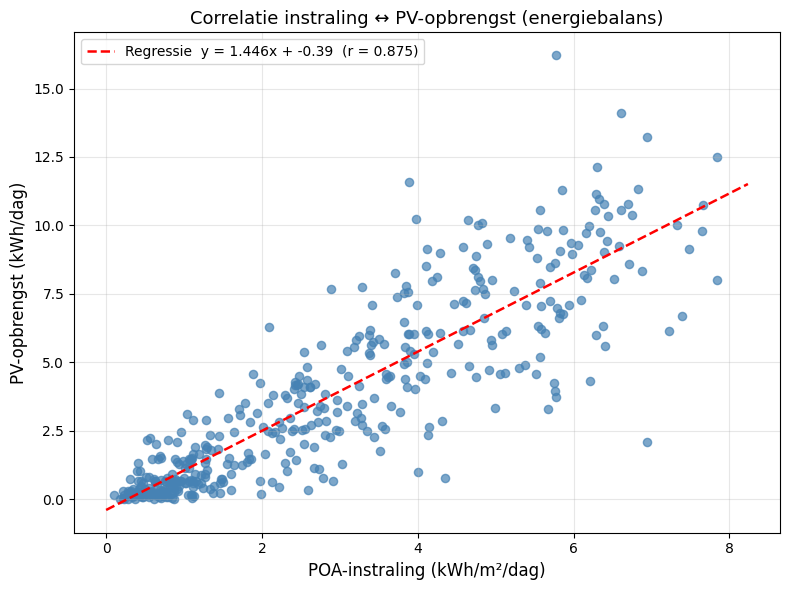


Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\pv_opbrengst_analyse.csv  (424 rijen)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from scripts.config import FINAL_DIR

# Hulpkolommen opzetten als ze nog niet bestaan
if 'kwartier_van_dag' not in df.columns:
    df['kwartier_van_dag'] = (
        pd.to_datetime(df['kwartier']).dt.hour * 4
        + pd.to_datetime(df['kwartier']).dt.minute // 15
    )
if 'poa_kwh_kw' not in df.columns:
    df['poa_kwh_kw'] = df['weer_poa_w_m2'].fillna(0) * 0.25 / 1000
if 'ev_kwh' not in df.columns:
    df['ev_kwh'] = df['ev_energie_kwh'].fillna(0)
if 'datum' not in df.columns:
    df['datum'] = pd.to_datetime(df['kwartier']).dt.date
if 'bat_laden_kwh_kw' not in df.columns:
    df['bat_laden_kwh_kw'] = (
        df.get('bat_laden_kw', pd.Series(0, index=df.index)).fillna(0) * 0.25
    )
if 'bat_ontladen_kwh_kw' not in df.columns:
    df['bat_ontladen_kwh_kw'] = (
        df.get('bat_ontladen_kw', pd.Series(0, index=df.index)).fillna(0) * 0.25
    )

# ── Stap 1: basisverbruiksprofiel (geen zon, geen EV, geen batterij) ────────
# Mediaan netafname per kwartier van de dag wanneer geen externe factor aanwezig.
mask_basis = (
    (df['poa_kwh_kw'] < 0.001) &
    (df['ev_kwh'] == 0) &
    (df['bat_laden_kwh_kw'].fillna(0) < 0.01) &
    (df['bat_ontladen_kwh_kw'].fillna(0) < 0.01)
)
basis_profiel = (
    df[mask_basis]
    .groupby('kwartier_van_dag')['afname_kwh']
    .median()
)
df['basis_verbruik_kwh'] = df['kwartier_van_dag'].map(basis_profiel)

print(f'Basiskwartieren (geen zon/EV/bat): {mask_basis.sum()}')
print(f'Gem. basisverbruik over dag      : {basis_profiel.mean():.4f} kWh/kwartier '
      f'= {basis_profiel.mean() * 96:.2f} kWh/dag')

# ── Stap 2: PV-yield via energiebalans ──────────────────────────────────────
# Energiebalans per kwartier:
#   PV + afname + bat_ontladen = verbruik_huis + ev_kwh + injectie + bat_laden
# → pv_yield = basis_verbruik + ev_kwh + injectie + bat_laden - bat_ontladen - afname
#
# Enkel geldig bij instraling (POA > 0); 's nachts = 0.
# Negatieve waarden (meetruis, afwijkend verbruik) worden weggeclipt.

df['pv_yield_kwh'] = (
    df['basis_verbruik_kwh']
    + df['ev_kwh']
    + df['injectie_kwh']
    + df['bat_laden_kwh_kw']
    - df['bat_ontladen_kwh_kw']
    - df['afname_kwh']
).where(df['poa_kwh_kw'] > 0.001, other=0).clip(lower=0)

print(f'\nPV-yield kwartieren (POA > 0): {(df["pv_yield_kwh"] > 0).sum()}')
print(f'Gem. PV-yield per kwartier  : {df["pv_yield_kwh"].mean():.4f} kWh')

# ── Stap 3: dagtotalen ──────────────────────────────────────────────────────
dag_pv = df.groupby('datum').agg(
    poa_kwh_m2       = ('poa_kwh_kw',         'sum'),
    pv_yield_kwh     = ('pv_yield_kwh',        'sum'),
    injectie_kwh     = ('injectie_kwh',        'sum'),
    bat_laden_kwh    = ('bat_laden_kwh_kw',    'sum'),
    bat_ontladen_kwh = ('bat_ontladen_kwh_kw', 'sum'),
    n_kw             = ('kwartier',            'count'),
).round(4)
dag_pv.index = pd.to_datetime(dag_pv.index)
dag_pv['maand'] = dag_pv.index.to_period('M')

# Enkel dagen met zon (POA > 0.1 kWh/m2 en yield > 0)
dag_zon = dag_pv[
    (dag_pv['poa_kwh_m2'] > 0.1) &
    (dag_pv['pv_yield_kwh'] > 0)
].copy()
dag_zon['rendement'] = dag_zon['pv_yield_kwh'] / dag_zon['poa_kwh_m2']

# ── Stap 4: regressie en correlatie ────────────────────────────────────────
coef = np.polyfit(dag_zon['poa_kwh_m2'], dag_zon['pv_yield_kwh'], 1)
r    = dag_zon['poa_kwh_m2'].corr(dag_zon['pv_yield_kwh'])

print(f'\nZonnige dagen in dataset        : {len(dag_zon)}')
print(f'Correlatie POA \u2194 PV-yield       : r = {r:.3f}')
print(f'Regressie: pv_yield = {coef[0]:.4f} \u00d7 poa + {coef[1]:.3f}')
print(f'  \u2192 systeemfactor (helling)      : {coef[0]:.3f} kWh/(kWh/m\u00b2)')
print(f'Gem. rendement                  : {dag_zon["rendement"].mean():.3f} kWh/(kWh/m\u00b2)')

# Maandoverzicht
maand_tot = dag_zon.groupby('maand').agg(
    poa_kwh_m2       = ('poa_kwh_m2',       'sum'),
    pv_yield_kwh     = ('pv_yield_kwh',      'sum'),
    injectie_kwh     = ('injectie_kwh',      'sum'),
    bat_laden_kwh    = ('bat_laden_kwh',     'sum'),
    bat_ontladen_kwh = ('bat_ontladen_kwh',  'sum'),
    rendement        = ('rendement',         'mean'),
    n_dagen          = ('pv_yield_kwh',      'count'),
).round(3)
maand_tot['zelfcons_kwh']  = (
    maand_tot['pv_yield_kwh'] - maand_tot['injectie_kwh']
).clip(lower=0)
maand_tot['zelfcons_frac'] = (
    maand_tot['zelfcons_kwh'] / maand_tot['pv_yield_kwh']
).round(3)

print('\nMAANDOVERZICHT:')
poa_hdr = "POA kWh/m²"
kop = f'  {"Maand":<10} {poa_hdr:>12} {"PV kWh":>8} {"Inj. kWh":>10} {"Bat+ kWh":>9} {"Bat- kWh":>9} {"Zelfcons.":>9} {"Rendem.":>9} {"Dagen":>6}'
print(kop)
print('  ' + '-' * 90)
for per, r_m in maand_tot.iterrows():
    print(
        f'  {str(per):<10} {r_m["poa_kwh_m2"]:>12.1f} {r_m["pv_yield_kwh"]:>8.1f}'
        f' {r_m["injectie_kwh"]:>10.1f} {r_m["bat_laden_kwh"]:>9.1f}'
        f' {r_m["bat_ontladen_kwh"]:>9.1f}'
        f' {r_m["zelfcons_frac"]:>9.1%} {r_m["rendement"]:>9.3f} {int(r_m["n_dagen"]):>6}'
    )

# ── Grafiek: correlatie instraling vs PV-opbrengst ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(dag_zon['poa_kwh_m2'], dag_zon['pv_yield_kwh'],
           s=35, alpha=0.70, color='steelblue')

x_l = np.linspace(0, dag_zon['poa_kwh_m2'].max() * 1.05, 200)
ax.plot(x_l, np.polyval(coef, x_l), 'r--', lw=1.8,
        label=f'Regressie  y = {coef[0]:.3f}x + {coef[1]:.2f}  (r = {r:.3f})')

ax.set_xlabel('POA-instraling (kWh/m²/dag)', fontsize=12)
ax.set_ylabel('PV-opbrengst (kWh/dag)', fontsize=12)
ax.set_title('Correlatie instraling ↔ PV-opbrengst (energiebalans)', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Opslaan ─────────────────────────────────────────────────────────────────
pad_pv = FINAL_DIR / 'pv_opbrengst_analyse.csv'
dag_zon.index.name = 'datum'
dag_zon.to_csv(pad_pv)
print(f'\nOpgeslagen: {pad_pv}  ({len(dag_zon)} rijen)')


### Conclusies PV-opbrengst

**Methode**

De PV-opbrengst wordt berekend via de energiebalans, waarbij het gemiddelde
huishoudelijk verbruiksprofiel als referentie dient. Door batterij- en EV-stromen
expliciet te verrekenen, is de berekening geldig voor **alle zonnige kwartieren** —
ook op dagen met batterijactiviteit. Dat geeft een grotere en meer representatieve
steekproef dan de vroegere aanpak (enkel batterijvrije dagen).

**Rendement en regressie**

De helling van de regressielijn (`kWh PV per kWh/m² POA`) weerspiegelt de
effectieve systeemgrootte (paneeloppervlak × efficiëntie × PR). De correlatie
tussen POA-instraling en PV-opbrengst valideert de methode.

**Zelfconsumptie**

Zelfconsumptie omvat zowel rechtstreeks huisverbruik als energie die naar de
batterij gaat. De fractie varieert per seizoen: in de winter is de fractie hoog
(weinig productie, alles verbruikt), in de zomer laag (veel productie, groot deel
naar het net).

**Beperking**

Het basisverbruiksprofiel is een mediaan en varieert dag tot dag. Afwijkingen
(ongewone verwarmingsvraag, aanwezigheidspatroon) introduceren ruis in de
individuele kwartierwaarden, maar middelen uit over een langere periode.


## 6. Gecorrigeerd thuisverbruik (inclusief PV-zelfconsumptie)

Sectie 4 toonde de **netto belasting op externe bronnen**
(`verbruik_kwh`). Op zonnige middagen is die waarde lager dan het werkelijke
thuisverbruik omdat de PV-zelfconsumptie niet via de Fluvius-meter loopt.

De energiebalans-aanpak uit sectie 5 kon de PV-opbrengst alleen schatten in
kwartieren waar `basis_verbruik_kwh` bekend was — en dat basisverbruik is enkel
beschikbaar voor **donkere kwartieren** (POA < 4 W/m²). Rond de middag is er in
België altijd instraling, dus bleven die uren leeg.

### Aanpak: systeemfactor uit de regressie

De regressie in sectie 5 geeft de helling van de rechte
`pv_yield = helling × poa_dag + intercept`. Die helling is de
**systeemfactor**: hoeveel kWh PV het systeem produceert per kWh/m² POA-instraling.
Ze is afgeleid uit de dagelijkse energiebalans en dus gebaseerd op
geïntegreerde metingen — betrouwbaarder dan de vroegere injectie-over-POA-benadering.

Per kwartier geldt dezelfde verhouding (de factor is tijdsonafhankelijk):

```
pv_geschat_kwh  = poa_kwh_kw × systeemfactor
verbruik_huis   = verbruik_kwh + pv_geschat_kwh
```

Dit geeft voor **elk uur van de dag** een schatting van het werkelijke
thuisverbruik, ook rond de middag.


Systeemfactor overgenomen uit sectie 5: 1.4456 kWh/(kWh/m²)
Gem. verbruik_kwh      : 0.1779 kWh/kwartier
Gem. pv_geschat_kwh    : 0.0359 kWh/kwartier
Gem. verbruik_huis_kwh : 0.2138 kWh/kwartier
  = 20.52 kWh/dag (gem. over alle dagen)


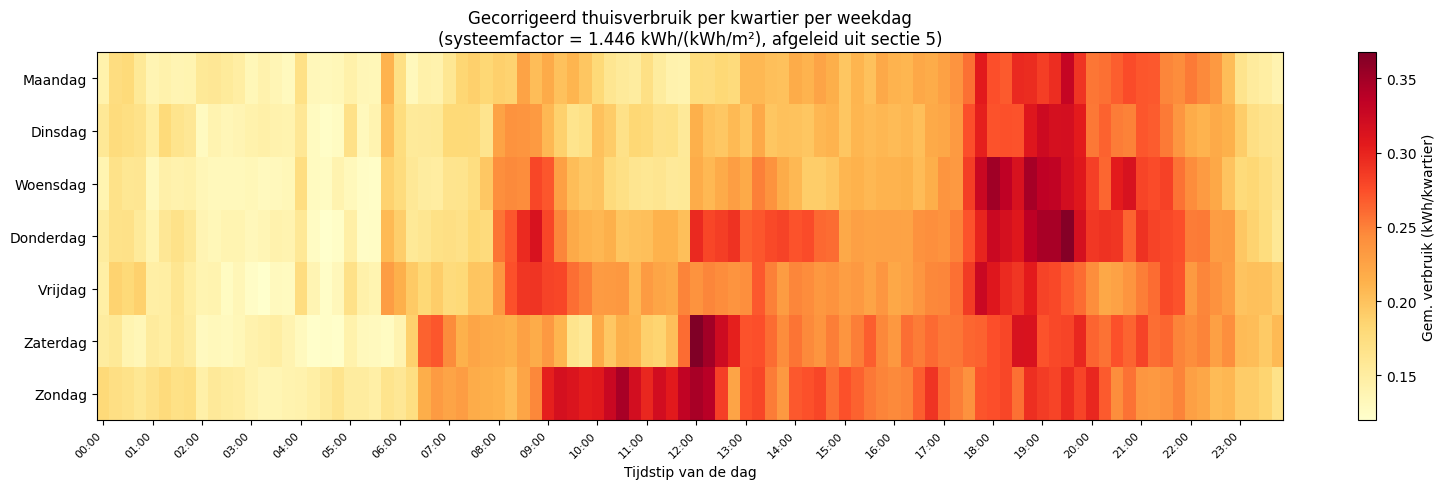

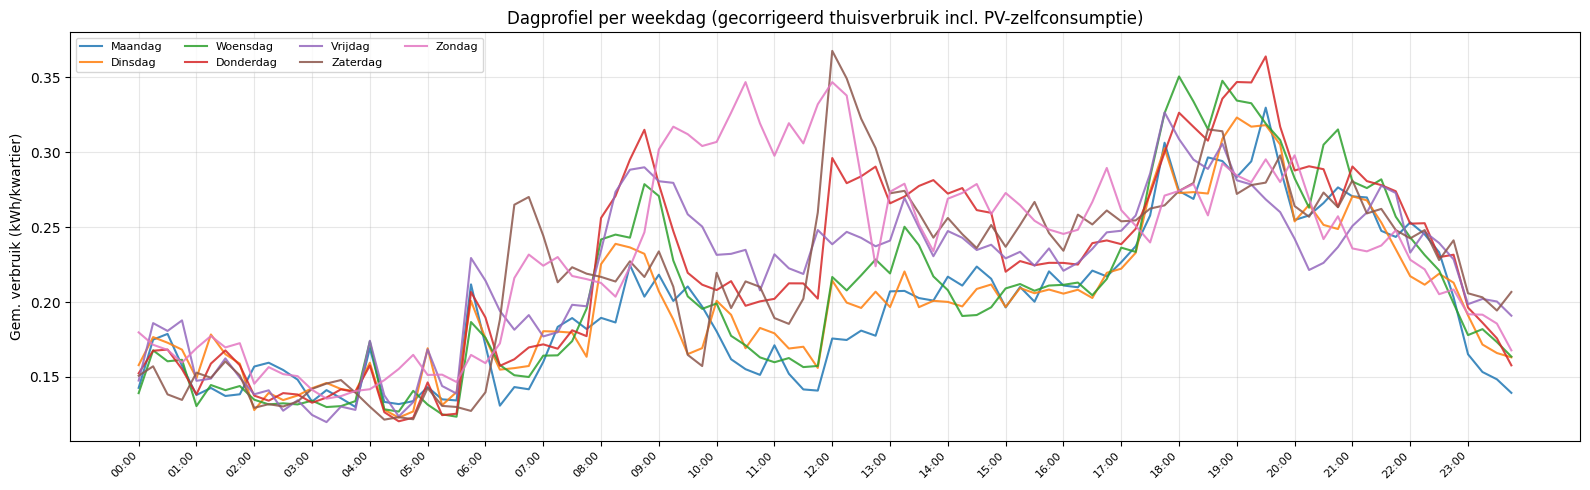

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ── Systeemfactor ophalen of herberekenen ─────────────────────────────────────────────
# coef[0] = helling van de regressie uit sectie 5
#         = kWh PV per kWh/m² POA (systeemfactor)
# Als sectie 5 nog niet is uitgevoerd, wordt de factor hier herberekend.
if 'coef' in dir() and hasattr(coef, '__len__') and len(coef) >= 1:
    systeemfactor = float(coef[0])
    print(f'Systeemfactor overgenomen uit sectie 5: {systeemfactor:.4f} kWh/(kWh/m²)')
elif 'pv_yield_kwh' in df.columns and 'poa_kwh_kw' in df.columns:
    # Herbereken dagtotalen en regressie
    if 'datum' not in df.columns:
        df['datum'] = pd.to_datetime(df['kwartier']).dt.date
    dag_herb = df.groupby('datum').agg(
        poa_kwh_m2   = ('poa_kwh_kw',     'sum'),
        pv_yield_kwh = ('pv_yield_kwh',    'sum'),
    )
    dag_herb = dag_herb[(dag_herb['poa_kwh_m2'] > 0.1) & (dag_herb['pv_yield_kwh'] > 0)]
    coef_herb = np.polyfit(dag_herb['poa_kwh_m2'], dag_herb['pv_yield_kwh'], 1)
    systeemfactor = float(coef_herb[0])
    print(f'Systeemfactor herberekend: {systeemfactor:.4f} kWh/(kWh/m²)')
else:
    print('Voer eerst sectie 5 uit om de systeemfactor te bepalen.')
    systeemfactor = None

if systeemfactor is not None:
    # ── PV-schatting en gecorrigeerd thuisverbruik per kwartier ──────────────────────────
    # Hulpkolom poa_kwh_kw indien nog niet aanwezig
    if 'poa_kwh_kw' not in df.columns:
        df['poa_kwh_kw'] = df['weer_poa_w_m2'].fillna(0) * 0.25 / 1000

    # pv_geschat_kwh = instraling per kwartier * systeemfactor
    # 's Nachts is poa = 0, dus pv_geschat = 0 (automatisch correct).
    df['pv_geschat_kwh'] = (df['poa_kwh_kw'] * systeemfactor).clip(lower=0)

    # Gecorrigeerd thuisverbruik: verbruik van externe bronnen + PV-zelfconsumptie
    df['verbruik_huis_kwh'] = (df['verbruik_kwh'] + df['pv_geschat_kwh']).clip(lower=0)

    print(f'Gem. verbruik_kwh      : {df["verbruik_kwh"].mean():.4f} kWh/kwartier')
    print(f'Gem. pv_geschat_kwh    : {df["pv_geschat_kwh"].mean():.4f} kWh/kwartier')
    print(f'Gem. verbruik_huis_kwh : {df["verbruik_huis_kwh"].mean():.4f} kWh/kwartier')
    print(f'  = {df["verbruik_huis_kwh"].mean()*96:.2f} kWh/dag (gem. over alle dagen)')

    # ── Weekpatroon ─────────────────────────────────────────────────────────────────────────
    WEEKDAGEN = ['Maandag','Dinsdag','Woensdag','Donderdag','Vrijdag','Zaterdag','Zondag']

    if 'dag_van_week' not in df.columns:
        df['dag_van_week'] = pd.to_datetime(df['kwartier']).dt.dayofweek
    if 'kwartier_van_dag' not in df.columns:
        df['kwartier_van_dag'] = (
            pd.to_datetime(df['kwartier']).dt.hour * 4
            + pd.to_datetime(df['kwartier']).dt.minute // 15
        )

    week = (
        df.groupby(['dag_van_week', 'kwartier_van_dag'])['verbruik_huis_kwh']
        .mean()
        .unstack(level=0)
    )
    week.columns = [WEEKDAGEN[i] for i in week.columns]

    tijdlabels = [
        f'{h:02d}:{m:02d}'
        for h in range(24) for m in (0, 15, 30, 45)
    ]
    uur_ticks = list(range(0, 96, 4))

    # ── Heatmap ────────────────────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(
        week.T.values,
        aspect='auto',
        cmap='YlOrRd',
        interpolation='nearest',
    )
    plt.colorbar(im, ax=ax, label='Gem. verbruik (kWh/kwartier)')
    ax.set_yticks(range(7))
    ax.set_yticklabels(WEEKDAGEN)
    ax.set_xticks(uur_ticks)
    ax.set_xticklabels([tijdlabels[i] for i in uur_ticks], rotation=45, ha='right', fontsize=8)
    ax.set_title(
        f'Gecorrigeerd thuisverbruik per kwartier per weekdag\n'
        f'(systeemfactor = {systeemfactor:.3f} kWh/(kWh/m²), afgeleid uit sectie 5)'
    )
    ax.set_xlabel('Tijdstip van de dag')
    plt.tight_layout()
    plt.show()

    # ── Lijnplot ─────────────────────────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 5))
    kleuren = plt.cm.tab10.colors
    for i, dag in enumerate(WEEKDAGEN):
        ax.plot(range(96), week[dag], color=kleuren[i], lw=1.5, label=dag, alpha=0.85)
    ax.set_xticks(uur_ticks)
    ax.set_xticklabels([tijdlabels[i] for i in uur_ticks], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Gem. verbruik (kWh/kwartier)')
    ax.set_title('Dagprofiel per weekdag (gecorrigeerd thuisverbruik incl. PV-zelfconsumptie)')
    ax.legend(loc='upper left', fontsize=8, ncol=4)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
